Imports

In [12]:
!pip install networkx
!pip install pennylane
!pip install pandas


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 9.0 MB/s  0:00:01 eta 0:00:01m

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [7]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

# Import the core logic from your unified engine
from l_vqe_engine import (
    build_k_community_hamiltonian,
    best_known_community_cost,
    simulate_one_lvqe,
    total_qubits
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


=== 1. GRAPH SETUP & BASELINE ===


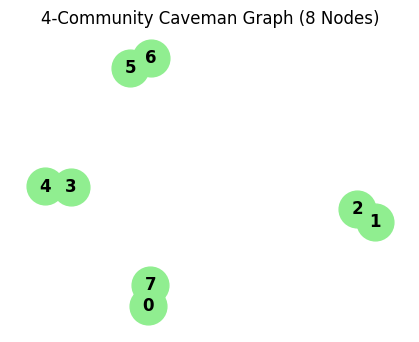

Calculating exact classical baseline...
True Maximum Modularity (C_bkv): 0.750000
Total Qubits Required: 16


In [8]:
print("=== 1. GRAPH SETUP & BASELINE ===")

# Generate the 8-node (4 communities of 2 nodes) Caveman Graph
G_test = nx.connected_caveman_graph(l=4, k=2)
k_target = 4
n_nodes = G_test.number_of_nodes()
n_qubits = total_qubits(n_nodes, k_target)

# Visualize the graph
plt.figure(figsize=(4, 3))
nx.draw(G_test,  with_labels=True, 
    node_color='lightgreen', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=700)
plt.title(f"4-Community Caveman Graph ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline using the exact modularity math
print("Calculating exact classical baseline...")
true_baseline = best_known_community_cost(G_test, k=k_target)
print(f"True Maximum Modularity (C_bkv): {true_baseline:.6f}")
print(f"Total Qubits Required: {n_qubits}")

In [9]:
print("\n=== 2. L-VQE (COBYLA) EXECUTION ===")

# Build the exact qubit-frugal Hamiltonian
H_comm = build_k_community_hamiltonian(G_test, k_target)

# Run L-VQE with COBYLA
rng_cobyla = np.random.default_rng(42)
cobyla_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,               # Statevector simulation
    max_iter_per_layer=600,   # Gives the 3,000 total budget
    rng=rng_cobyla,
    optimizer="COBYLA",
    device_name="lightning.qubit"
)

# Remember: VQE minimizes cost (negative modularity), so we flip the sign
cobyla_modularity = -cobyla_results['final_cost']
cobyla_rho = cobyla_modularity / true_baseline

print(f"\nCOBYLA Final Modularity: {cobyla_modularity:.6f}")
print(f"COBYLA Approximation Ratio (ρ): {cobyla_rho:.4f}")


=== 2. L-VQE (COBYLA) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.750000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000

COBYLA Final Modularity: 0.750000
COBYLA Approximation Ratio (ρ): 1.0000


In [41]:
print("\n=== 3. L-VQE (SMO) EXECUTION ===")

# We use the exact same random seed so both optimizers start on the exact same point on the mountain
rng_smo = np.random.default_rng(42) 

smo_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_smo,
    optimizer="SMO",
    device_name="lightning.qubit"
)

smo_modularity = -smo_results['final_cost']
smo_rho = smo_modularity / true_baseline

print(f"\nSMO Final Modularity: {smo_modularity:.6f}")
print(f"SMO Approximation Ratio (ρ): {smo_rho:.4f}")


=== 3. L-VQE (SMO) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000

SMO Final Modularity: 0.750000
SMO Approximation Ratio (ρ): 1.0000



=== 4. OPTIMIZER TRAJECTORY COMPARISON ===


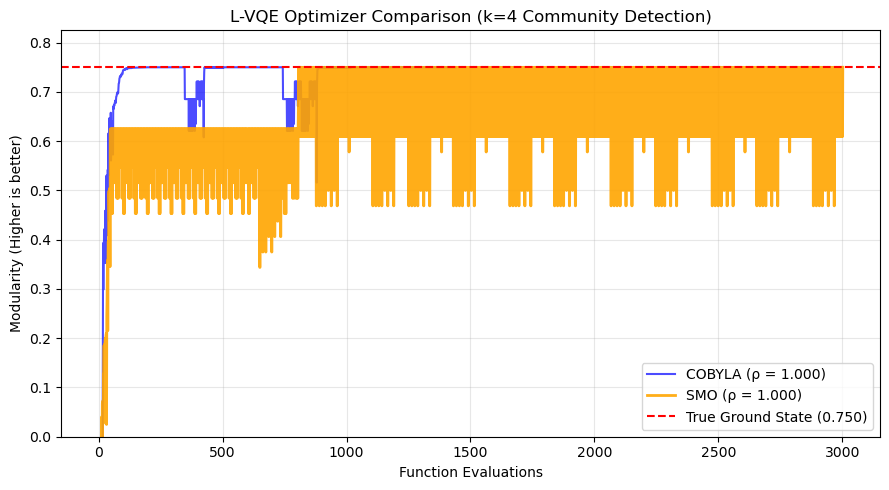

In [42]:
print("\n=== 4. OPTIMIZER TRAJECTORY COMPARISON ===")
plt.figure(figsize=(9, 5))

# Convert VQE costs back to positive modularity for the plot
plt.plot([-c for c in cobyla_results["cost_history"]], label=f"COBYLA (ρ = {cobyla_rho:.3f})", color='blue', alpha=0.7)
plt.plot([-c for c in smo_results["cost_history"]], label=f"SMO (ρ = {smo_rho:.3f})", color='orange', alpha=0.9, linewidth=2)

# Plot the absolute classical ceiling
plt.axhline(true_baseline, color="red", linestyle="--", linewidth=1.5, label=f"True Ground State ({true_baseline:.3f})")

plt.title("L-VQE Optimizer Comparison (k=4 Community Detection)")
plt.xlabel("Function Evaluations")
plt.ylabel("Modularity (Higher is better)")
plt.ylim(0, true_baseline * 1.1)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== 1. GRAPH SETUP & BASELINE (Ring of Cliques) ===


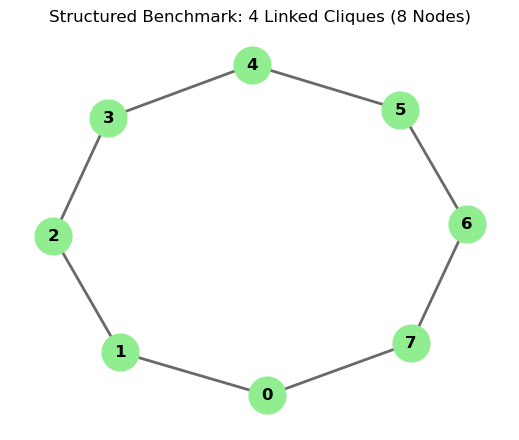

Calculating exact classical baseline...
True Maximum Modularity (C_bkv): 0.281250
Total Qubits Required: 16


In [43]:
print("=== 1. GRAPH SETUP & BASELINE (Ring of Cliques) ===")

# Generate a highly structured graph: 4 distinct cliques, connected in a ring.
# 4 cliques * 2 nodes each = 8 nodes total. 
# This guarantees a perfect, high-fidelity 4-community landscape.
G_simple = nx.ring_of_cliques(num_cliques=4, clique_size=2)
k_target = 4
n_nodes = G_simple.number_of_nodes()
n_qubits = total_qubits(n_nodes, k_target)

# VISUALIZATION
plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G_simple, seed=42) 
nx.draw(
    G_simple, 
    pos, 
    with_labels=True, 
    node_color='lightgreen', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=700
)
plt.title(f"Structured Benchmark: 4 Linked Cliques ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline
print("Calculating exact classical baseline...")
true_baseline = best_known_community_cost(G_simple, k=k_target)
print(f"True Maximum Modularity (C_bkv): {true_baseline_simple:.6f}")
print(f"Total Qubits Required: {n_qubits}")

In [44]:
print("\n=== 2. L-VQE (COBYLA) EXECUTION ===")

# Build the exact qubit-frugal Hamiltonian
H_comm = build_k_community_hamiltonian(G_simple, k_target)

# Run L-VQE with COBYLA
rng_cobyla = np.random.default_rng(42)
cobyla_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,               # Statevector simulation
    max_iter_per_layer=600,   # Gives the 3,000 total budget
    rng=rng_cobyla,
    optimizer="COBYLA",
    device_name="lightning.qubit"
)

# Remember: VQE minimizes cost (negative modularity), so we flip the sign
cobyla_modularity = -cobyla_results['final_cost']
cobyla_rho = cobyla_modularity / true_baseline

print(f"\nCOBYLA Final Modularity: {cobyla_modularity:.6f}")
print(f"COBYLA Approximation Ratio (ρ): {cobyla_rho:.4f}")


=== 2. L-VQE (COBYLA) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.281246
  Layer 1  (76 params) ... cost = -0.281249
  Layer 2  (136 params) ... cost = -0.281250

COBYLA Final Modularity: 0.281250
COBYLA Approximation Ratio (ρ): 1.0000


In [45]:
print("\n=== 3. L-VQE (SMO) EXECUTION ===")

# We use the exact same random seed so both optimizers start on the exact same point on the mountain
rng_smo = np.random.default_rng(42) 

smo_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_smo,
    optimizer="SMO",
    device_name="lightning.qubit"
)

smo_modularity = -smo_results['final_cost']
smo_rho = smo_modularity / true_baseline

print(f"\nSMO Final Modularity: {smo_modularity:.6f}")
print(f"SMO Approximation Ratio (ρ): {smo_rho:.4f}")


=== 3. L-VQE (SMO) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.250000
  Layer 1  (76 params) ... cost = -0.281250
  Layer 2  (136 params) ... cost = -0.281250

SMO Final Modularity: 0.281250
SMO Approximation Ratio (ρ): 1.0000



=== 4. OPTIMIZER TRAJECTORY COMPARISON ===


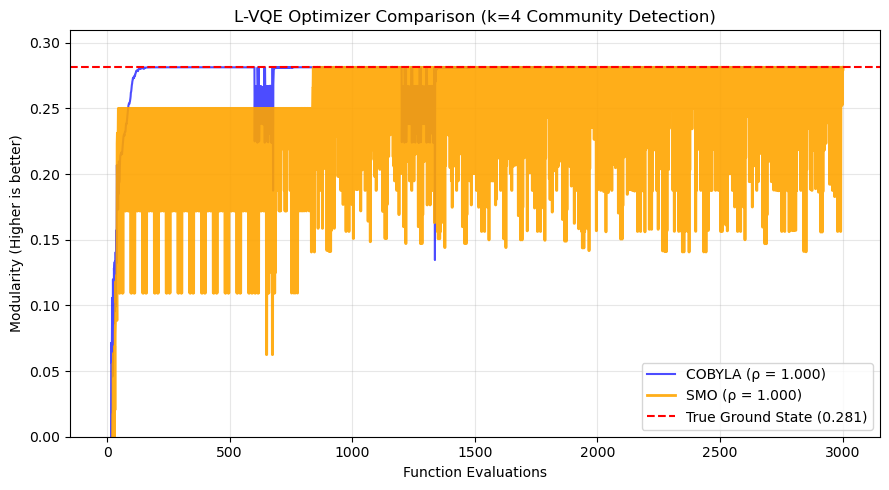

In [46]:
print("\n=== 4. OPTIMIZER TRAJECTORY COMPARISON ===")
plt.figure(figsize=(9, 5))

# Convert VQE costs back to positive modularity for the plot
plt.plot([-c for c in cobyla_results["cost_history"]], label=f"COBYLA (ρ = {cobyla_rho:.3f})", color='blue', alpha=0.7)
plt.plot([-c for c in smo_results["cost_history"]], label=f"SMO (ρ = {smo_rho:.3f})", color='orange', alpha=0.9, linewidth=2)

# Plot the absolute classical ceiling
plt.axhline(true_baseline, color="red", linestyle="--", linewidth=1.5, label=f"True Ground State ({true_baseline:.3f})")

plt.title("L-VQE Optimizer Comparison (k=4 Community Detection)")
plt.xlabel("Function Evaluations")
plt.ylabel("Modularity (Higher is better)")
plt.ylim(0, true_baseline * 1.1)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import time
import pandas as pd
import numpy as np
import networkx as nx
import pennylane as qml
from pennylane import numpy as pnp # Precautionary as requested

# Import from your engine
from l_vqe_engine import (
    build_k_community_hamiltonian,
    best_known_community_cost,
    simulate_one_lvqe,
    simulate_one_qaoa,
    total_qubits
)

print("=== STARTING MASSIVE BATCH ANALYSIS ===")

# --- Configuration ---
graph_sizes = [7, 8, 9, 10]
n_seeds = 10
k_target = 4
device = "lightning.qubit"  # Fast statevector backend

# Budgets
lvqe_evals_per_layer = 600  # Yields 3,000 total (600 + 600 + 1800)
qaoa_evals = 3000           # Gives QAOA the exact same 3,000 budget per run
qaoa_p_values = list(range(1, 11)) # p = 1 to 10

# Master data collection list
results_data = []

for n_nodes in graph_sizes:
    print(f"\n--- Processing Graph: {n_nodes} Nodes ---")
    
    # 1. Generate the exact topology used in the paper
    G = nx.erdos_renyi_graph(n_nodes, p=0.5, seed=42)
    n_q = total_qubits(n_nodes, k_target)
    
    print(f"Calculating true baseline for {n_nodes} nodes...")
    true_baseline = best_known_community_cost(G, k=k_target)
    print('True Baseline:',true_baseline)
    H_comm = build_k_community_hamiltonian(G, k_target)
    
    for seed in range(n_seeds):
        print(f"  Running Seed {seed+1}/{n_seeds}...")
        rng = np.random.default_rng(seed)
        
        # --- A. L-VQE (SMO) ---
        print('L-VQE(SMO):')
        t0 = time.time()
        res_smo = simulate_one_lvqe(
            n_q, H_comm, max_layers=2, shots=None, 
            max_iter_per_layer=lvqe_evals_per_layer, 
            rng=rng, device_name=device, optimizer="SMO"
        )
        rho_smo = -res_smo['final_cost'] / true_baseline
        entry = {"Algorithm": "L-VQE (SMO)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_smo, "Time_s": time.time()-t0}
        results_data.append(entry)
        #print(entry)

        # --- B. L-VQE (COBYLA) ---
        print('L-VQE(COBYLA):')
        t0 = time.time()
        res_cobyla = simulate_one_lvqe(
            n_q, H_comm, max_layers=2, shots=None, 
            max_iter_per_layer=lvqe_evals_per_layer, 
            rng=rng, device_name=device, optimizer="COBYLA"
        )
        rho_cobyla = -res_cobyla['final_cost'] / true_baseline
        entry = {"Algorithm": "L-VQE (COBYLA)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_cobyla, "Time_s": time.time()-t0}
        results_data.append(entry)
        #print(entry)

        #--- C. QAOA (p = 1 to 10) ---
        print('QAOA:')
        for p in qaoa_p_values:
            print("p =",p)
            t0 = time.time()
            res_qaoa = simulate_one_qaoa(
                n_q, H_comm, p_steps=p, shots=None, 
                max_evals=qaoa_evals, rng=rng, device_name=device
            )
            rho_qaoa = -res_qaoa['final_cost'] / true_baseline
            results_data.append({"Algorithm": "QAOA", "Nodes": n_nodes, "Seed": seed, "p_or_L": p, "Rho": rho_qaoa, "Time_s": time.time()-t0})

# --- Compile and Export ---
print("\n=== ANALYSIS COMPLETE. COMPILING DATA ===")
df_results = pd.DataFrame(results_data)
csv_filename = "data_community_benchmark.csv"
df_results.to_csv(csv_filename, index=False)
print(f"Data successfully exported to '{csv_filename}'.")

# Display a quick preview of the average performance
display(df_results.groupby(['Algorithm', 'Nodes', 'p_or_L'])['Rho'].mean().unstack(level=0))

=== STARTING MASSIVE BATCH ANALYSIS ===

--- Processing Graph: 7 Nodes ---
Calculating true baseline for 7 nodes...
True Baseline: 0.13223140495867766
  Running Seed 1/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
L-VQE(COBYLA):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
QAOA:
p = 1
p = 2
p = 3
p = 4
p = 5
p = 6
p = 7
p = 8
p = 9
p = 10
  Running Seed 2/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.099174
  Layer 1  (66 params) ... cost = -0.099174
  Layer 2  (118 params) ... cost = -0.099174
L-VQE(COBYLA):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
QAOA:
p = 1
p = 2
p = 3
p = 4
p = 5
p = 6
p = 7
p = 8
p = 9
p = 10
  Running Seed 3/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.132231
  La

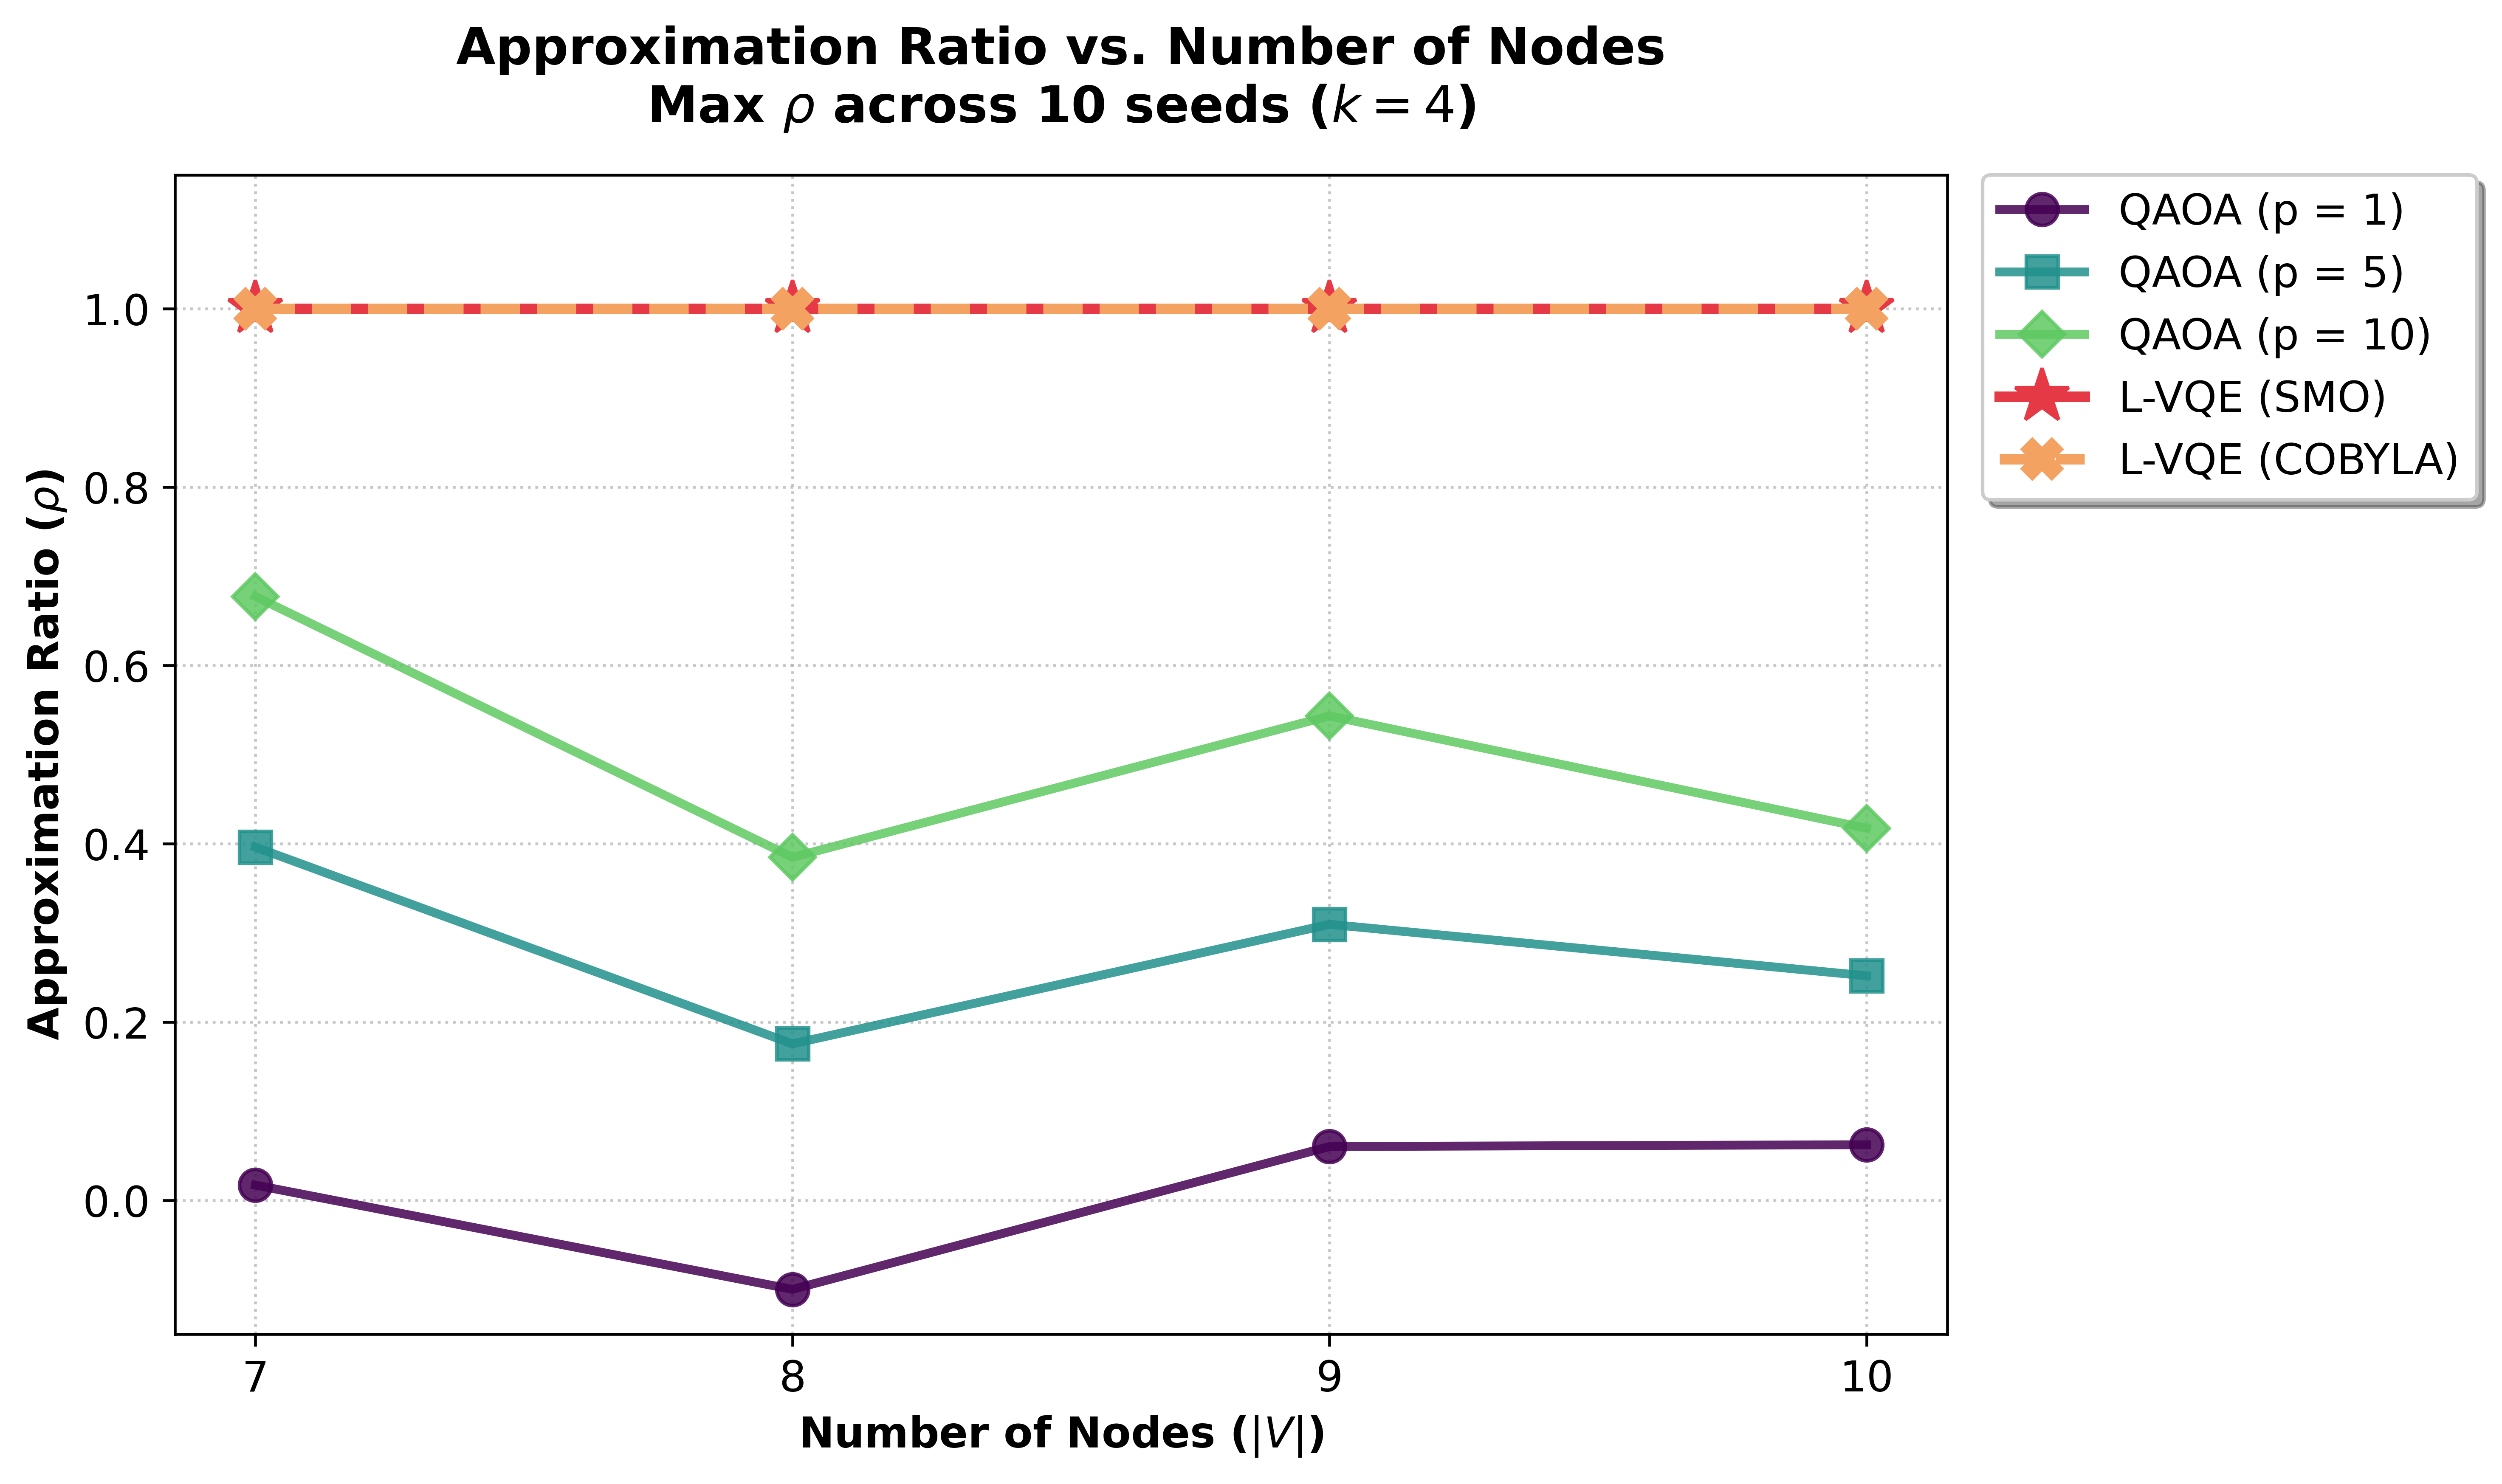

In [71]:
# Optional but highly recommended for Jupyter Notebooks:
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


csv_filename = "data_community_benchmark.csv"
df = pd.read_csv(csv_filename)
df_best = df.groupby(['Algorithm', 'Nodes', 'p_or_L'])['Rho'].max().reset_index()

plt.figure(figsize=(10, 6), dpi=300)
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

qaoa_data = df_best[df_best['Algorithm'] == 'QAOA']
target_p_values = [1, 5, 10]
qaoa_filtered = qaoa_data[qaoa_data['p_or_L'].isin(target_p_values)]

qaoa_colors = {1: '#440154', 5: '#21918c', 10: '#5ec962'}
qaoa_markers = {1: 'o', 5: 's', 10: 'D'}

for p in target_p_values:
    subset = qaoa_filtered[qaoa_filtered['p_or_L'] == p]
    if not subset.empty:
        plt.plot(
            subset['Nodes'], subset['Rho'], 
            marker=qaoa_markers[p], markersize=9, 
            color=qaoa_colors[p], linewidth=2.5, alpha=0.85, 
            label=f'QAOA (p = {p})'
        )

lvqe_smo = df_best[df_best['Algorithm'] == 'L-VQE (SMO)']
plt.plot(
    lvqe_smo['Nodes'], lvqe_smo['Rho'], 
    marker='*', markersize=16, 
    color='#E63946', linewidth=3,
    label='L-VQE (SMO)'
)

lvqe_cobyla = df_best[df_best['Algorithm'] == 'L-VQE (COBYLA)']
plt.plot(
    lvqe_cobyla['Nodes'], lvqe_cobyla['Rho'], 
    marker='X', markersize=11, 
    color='#F4A261', linewidth=3, linestyle='--',
    label='L-VQE (COBYLA)'
)

plt.title("Approximation Ratio vs. Number of Nodes\nMax $\\rho$ across 10 seeds ($k=4$)", fontweight='bold', pad=15)
plt.xlabel("Number of Nodes ($|V|$)", fontweight='bold')
plt.ylabel("Approximation Ratio ($\\rho$)", fontweight='bold')

plt.xticks([7, 8, 9, 10])

# --- UPDATED: Hardcoded identical limits ---
plt.ylim(-0.15, 1.15) 

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, framealpha=1.0, shadow=True)
plt.tight_layout()
plt.show()

In [72]:
# Optional but highly recommended for Jupyter Notebooks:
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('data_community_benchmark.csv')

# Configure a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
axes = axes.flatten() # Flatten the 2x2 matrix to easily loop through it

nodes_list = [7, 8, 9, 10]
labels = ['QAOA\n(p=1)', 'QAOA\n(p=5)', 'QAOA\n(p=10)', 'L-VQE\n(SMO)', 'L-VQE\n(COBYLA)']

# Colors matched to your previous line graphs!
colors = ['#440154', '#21918c', '#5ec962', '#E63946', '#F4A261'] 

for i, nodes in enumerate(nodes_list):
    df_n = df[df['Nodes'] == nodes]
    
    # Extract data arrays for each box
    q_1 = df_n[(df_n['Algorithm'] == 'QAOA') & (df_n['p_or_L'] == 1)]['Rho'].values
    q_5 = df_n[(df_n['Algorithm'] == 'QAOA') & (df_n['p_or_L'] == 5)]['Rho'].values
    q_10 = df_n[(df_n['Algorithm'] == 'QAOA') & (df_n['p_or_L'] == 10)]['Rho'].values
    l_smo = df_n[df_n['Algorithm'] == 'L-VQE (SMO)']['Rho'].values
    l_cob = df_n[df_n['Algorithm'] == 'L-VQE (COBYLA)']['Rho'].values
    
    # Handle empty arrays gracefully just in case
    data_to_plot = [
        q_1 if len(q_1) > 0 else [np.nan],
        q_5 if len(q_5) > 0 else [np.nan],
        q_10 if len(q_10) > 0 else [np.nan],
        l_smo if len(l_smo) > 0 else [np.nan],
        l_cob if len(l_cob) > 0 else [np.nan]
    ]
    
    # Create the boxplot for this specific node size
    box = axes[i].boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)
    
    # Apply the thematic colors
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        
    # Thicken the median line so it's readable on projectors
    for median in box['medians']:
        median.set(color='black', linewidth=2.5)
        
    # Format the subplot
    axes[i].set_title(f'{nodes}-Node Graph', fontweight='bold', fontsize=14)
    axes[i].set_ylim(-0.15, 1.1) # Unified Y-axis for direct comparison
    axes[i].grid(True, linestyle=':', alpha=0.7, axis='y')
    
    # Only label the outer left Y-axes to reduce clutter
    if i % 2 == 0:
        axes[i].set_ylabel('Approximation Ratio ($\\rho$)', fontweight='bold')

# Main layout adjustments
fig.suptitle("Variance & Robustness Across Network Sizes\nComparison of QAOA Depths vs. L-VQE", 
             fontweight='bold', fontsize=18, y=0.96)

# Leave room for the main title
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.show()

/tmp/ipykernel_866710/3708073170.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)
/tmp/ipykernel_866710/3708073170.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)
/tmp/ipykernel_866710/3708073170.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)
/tmp/ipykernel_866710/3708073170.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rename